In [1]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Input, Flatten, Dense, BatchNormalization, Dropout

In [2]:
train, test = tf.keras.datasets.fashion_mnist.load_data()

In [3]:
images, labels = train
images = images / 255.0
labels = labels.astype(np.int32)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.1)

In [5]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000).batch(64)

In [6]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(300, activation='relu'),
    Dense(150, activation='relu'),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='softmax')
])

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_ds,
    epochs=25,
    verbose=1
)

Epoch 1/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8147 - loss: 0.5181
Epoch 2/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8648 - loss: 0.3702
Epoch 3/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8771 - loss: 0.3357
Epoch 4/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8850 - loss: 0.3101
Epoch 5/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8917 - loss: 0.2910
Epoch 6/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8962 - loss: 0.2761
Epoch 7/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9008 - loss: 0.2661
Epoch 8/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9055 - loss: 0.2505
Epoch 9/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9083 - loss: 0.2429
Epoch 10/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9122 - loss: 0.2337
Epoch 11/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9139 - loss: 0.2258
Epoch 12/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

In [11]:
model.save("fashion_mnist_model.keras")

In [12]:
from tensorflow.keras.models import load_model
loaded_model = load_model("fashion_mnist_model.keras")

C:\Users\Tomasz\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 
               'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def predict_and_show(model, X, index):

    img = X[index]
    input_img = np.expand_dims(img, axis=0)
    
    pred_probs = model.predict(input_img)
    pred_class = np.argmax(pred_probs, axis=1)[0]
    
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {class_names[pred_class]}")
    plt.axis('off')
    plt.show()
    
    print("Probabilities:", pred_probs[0])
    print("Predicted class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


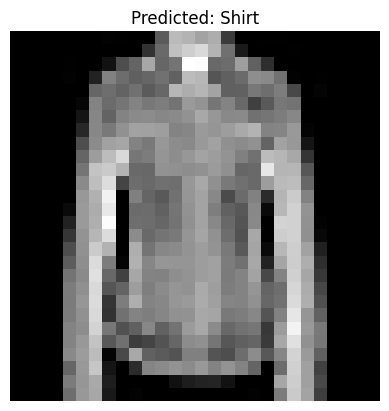

Probabilities: [6.8867623e-05 2.3307123e-06 2.6072850e-02 3.0044341e-05 1.1914086e-01
 2.8333766e-08 8.5467172e-01 1.9076715e-08 1.2984950e-05 2.3888077e-07]
Predicted class: 6


In [20]:
predict_and_show(model, X_test, index=5)

In [22]:
from tensorflow.keras import layers

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

model_aug = Sequential([
    Input(shape=(28, 28, 1)),
    data_augmentation,
    Flatten(),
    Dense(300, activation='relu'),
    Dense(150, activation='relu'),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='softmax')
])

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    train_ds,
    epochs=30,
    verbose=1
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9679 - loss: 0.0843
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9693 - loss: 0.0797
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9706 - loss: 0.0768
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9714 - loss: 0.0758
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9724 - loss: 0.0713
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9706 - loss: 0.0776
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9709 - loss: 0.0756
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9733 - loss: 0.0698
Epoch 9/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9732 - loss: 0.0724
Epoch 10/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9747 - loss: 0.0642
Epoch 11/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9740 - loss: 0.0681
Epoch 12/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step